How do the demographic profiles (sex, age, race, etc.) of the Thyroid Visit cohort compare with patients who received TSH, T3, or T4 testing? Does the data reflect expected real-world clinical trends, such as higher thyroid risk in women in their 40s and 50s?

## Step 1: Loading and Preparing the Cohorts
We import the required libraries and load the cleaned datasets, ensuring the diagnosed cohort is deduplicated by person_id to focus on patient-level rather than visit-level analysis.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# Load the cleaned data
df_diag = pd.read_csv('visits_analysis_ready.csv')
df_test = pd.read_csv('thyroid_testing_cohort.csv')

# Identify unique patients (Deduplication)
# 'thyroid_visit' represents the diagnosed population
# 'testing' represents the cohort that received lab tests
thyroid_visit = df_diag.drop_duplicates(subset='person_id').copy()
testing = df_test.copy()

print(f"Unique diagnosed patients: {len(thyroid_visit)}")
print(f"Unique tested patients: {len(testing)}")

Unique diagnosed patients: 32231
Unique tested patients: 42300


## Step 2: Standardizing Categorical Variables
To resolve discrepancies between clinical and laboratory systems (e.g., "Other" vs. "Unknown"), we apply harmonization functions to align gender, race, and ethnicity labels for an accurate comparison.

In [2]:
# Functions to harmonize categories between clinical and lab data
def harmonize_race(s):
    s = s.fillna("Unknown")
    mapping = {
        "White": "White",
        "Black or African American": "Black",
        "Asian": "Asian",
        "American Indian or Alaska Native": "AIAN",
        "Native Hawaiian or Other Pacific Islander": "NHPI",
        "Other": "Other/Unknown",
        "Unknown": "Other/Unknown"
    }
    return s.map(mapping).fillna("Other/Unknown")

def harmonize_ethnicity(s):
    s = s.fillna("Unknown")
    mapping = {
        "Not Hispanic or Latino": "Not Hispanic",
        "Hispanic or Latino": "Hispanic",
        "Other": "Other/Unknown",
        "Unknown": "Other/Unknown"
    }
    return s.map(mapping).fillna("Other/Unknown")

def harmonize_gender(s):
    s = s.fillna("Other/Unknown")
    return s.replace({"F": "Female", "M": "Male"}).where(lambda x: x.isin(["Female", "Male"]), "Other/Unknown")

# Apply harmonization
thyroid_visit["gender_grp"] = harmonize_gender(thyroid_visit["gender_clean"])
testing["gender_grp"] = harmonize_gender(testing["gender_clean"])

thyroid_visit["race_grp"] = harmonize_race(thyroid_visit["race_clean"])
testing["race_grp"] = harmonize_race(testing["race_clean"])

thyroid_visit["ethnicity_grp"] = harmonize_ethnicity(thyroid_visit["ethnicity_clean"])
testing["ethnicity_grp"] = harmonize_ethnicity(testing["ethnicity_clean"])

# Ensure age groups are handled consistently
thyroid_visit["age_group_cmp"] = thyroid_visit["age_group"].fillna("Missing")
testing["age_group_cmp"] = testing["age_group"].fillna("Missing") 

## Step 3: Creating the Visualization and Testing Framework

We define a unified function to generate comparative bar plots and perform Chi-square tests of independence, allowing us to statistically evaluate distribution differences between the two cohorts.

In [3]:
def run_distribution_analysis(df_diag, df_test, column, title):
    # 1. Create Contingency Table for Chi-square Test (using raw counts)
    diag_counts = df_diag[column].value_counts()
    test_counts = df_test[column].value_counts()
    
    # Combine counts into a single dataframe for the test
    contingency_table = pd.DataFrame({'Diagnosed': diag_counts, 'Tested': test_counts}).fillna(0)
    
    # Run Chi-square Test
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    
    # 2. Calculate Percentages for Visualization
    comparison_pct = (contingency_table / contingency_table.sum() * 100)
    
    # 3. Visualization
    ax = comparison_pct.plot(kind='bar', figsize=(10, 5), width=0.8, color=['#4C72B0', '#DD8452'])
    plt.title(f'Cohort Comparison by {title}', fontsize=14)
    plt.ylabel('Percentage within Cohort (%)')
    plt.xlabel(title)
    plt.xticks(rotation=45, ha='right') # Fix overlapping labels
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()
    
    # 4. Display Results
    print(f"--- Statistics for {title} ---")
    print(f"Chi-square p-value: {p:.4e}")
    if p < 0.05:
        print("Result: Statistically significant difference in distributions.")
    else:
        print("Result: No statistically significant difference observed.")
    display(comparison_pct.round(2))
    print("\n" + "="*50 + "\n")

## Step 4: Executing Multi-Variable Profile Analysis
We run the distribution analysis across gender, age, race, and ethnicity, including a targeted sub-analysis for the female cohort to address the specific clinical trends identified in our research question.

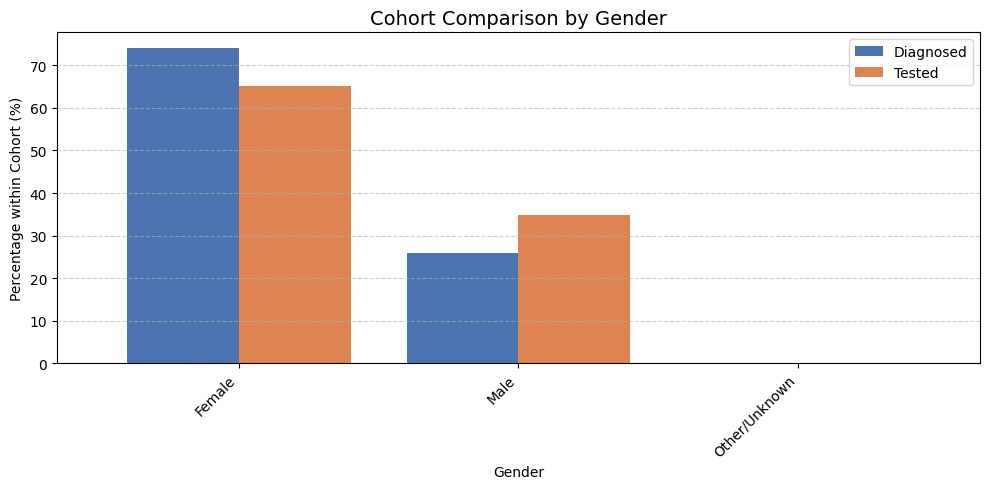

--- Statistics for Gender ---
Chi-square p-value: 5.7494e-149
Result: Statistically significant difference in distributions.


,Diagnosed,Tested
gender_grp,,
Female,74.07,65.24
Male,25.90,34.76
Other/Unknown,0.03,0.00


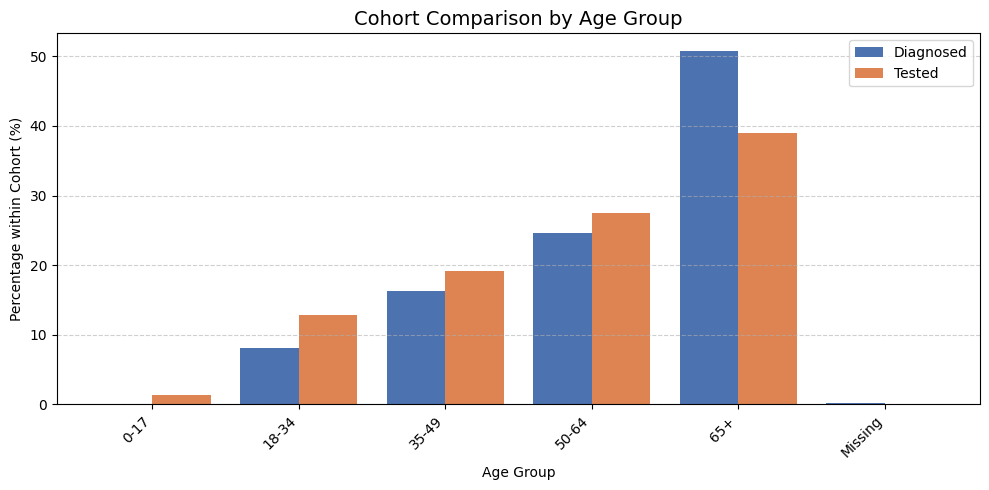

--- Statistics for Age Group ---
Chi-square p-value: 0.0000e+00
Result: Statistically significant difference in distributions.


,Diagnosed,Tested
age_group_cmp,,
0-17,0.00,1.38
18-34,8.05,12.88
35-49,16.24,19.18
50-64,24.68,27.51
65+,50.76,38.98
Missing,0.26,0.07


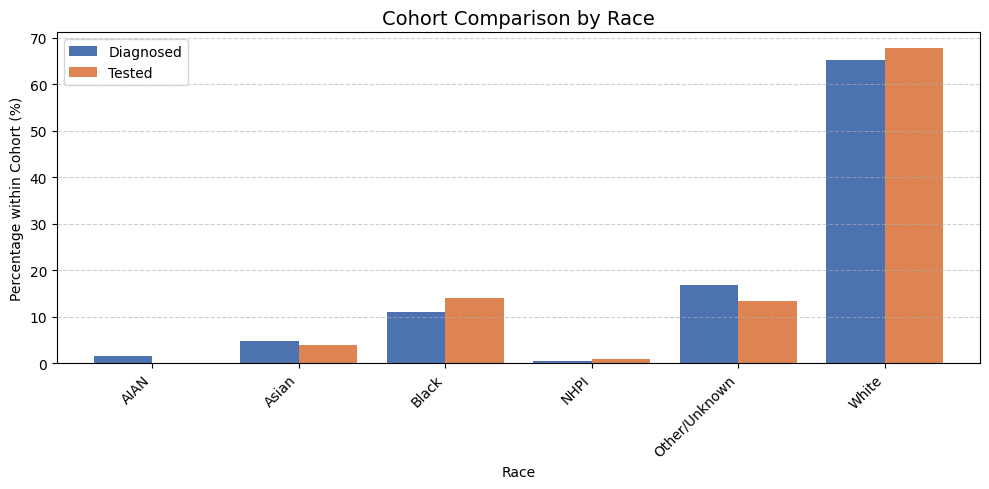

--- Statistics for Race ---
Chi-square p-value: 1.4887e-209
Result: Statistically significant difference in distributions.


,Diagnosed,Tested
race_grp,,
AIAN,1.59,0.06
Asian,4.86,3.91
Black,11.07,14.06
NHPI,0.42,0.88
Other/Unknown,16.83,13.31
White,65.24,67.78


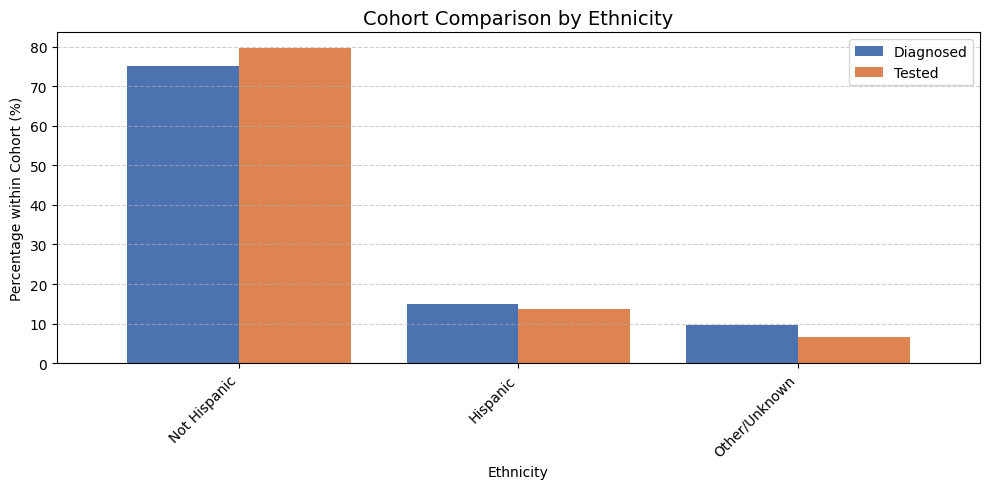

--- Statistics for Ethnicity ---
Chi-square p-value: 1.8977e-63
Result: Statistically significant difference in distributions.


,Diagnosed,Tested
ethnicity_grp,,
Not Hispanic,75.21,79.64
Hispanic,15.03,13.70
Other/Unknown,9.76,6.65


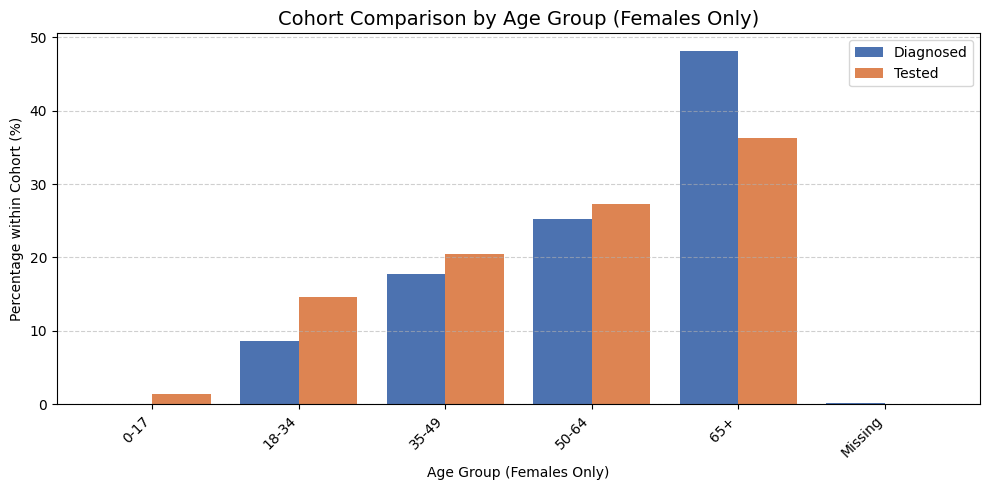

--- Statistics for Age Group (Females Only) ---
Chi-square p-value: 3.6330e-265
Result: Statistically significant difference in distributions.


,Diagnosed,Tested
age_group_cmp,,
0-17,0.00,1.40
18-34,8.68,14.62
35-49,17.78,20.45
50-64,25.17,27.23
65+,48.12,36.23
Missing,0.24,0.07


In [4]:
# Execute analysis for each demographic profile
run_distribution_analysis(thyroid_visit, testing, 'gender_grp', 'Gender')
run_distribution_analysis(thyroid_visit, testing, 'age_group_cmp', 'Age Group')
run_distribution_analysis(thyroid_visit, testing, 'race_grp', 'Race')
run_distribution_analysis(thyroid_visit, testing, 'ethnicity_grp', 'Ethnicity')

# Sub-analysis: Age distribution within Females only
female_diag = thyroid_visit[thyroid_visit['gender_grp'] == 'Female']
female_test = testing[testing['gender_grp'] == 'Female']
run_distribution_analysis(female_diag, female_test, 'age_group_cmp', 'Age Group (Females Only)')

## Demographic Comparison of Thyroid Cohorts

### 1. Statistical Overview
A Chi-square test for independence was conducted for all demographic variables to evaluate the relationship between the **Diagnosed cohort** and the **Testing cohort**. All tests yielded a p-value of **$p < 0.001$**, indicating that the distribution of patients significantly differs between the two cohorts across all categories.

* **Diagnosed Cohort (Visits):** 32,231 unique patients.
* **Testing Cohort (Labs):** 42,300 unique patients.

---

### 2. Key Findings

#### **Gender**
* **Finding:** Females represent **74.1%** of the diagnosed population, which is **directionally consistent** with the higher clinical burden of thyroid disease typically observed in women.
* **Observation:** In the testing cohort, however, the share of females is lower at **65.2%**. While the data reflects the expected higher risk for women, there is a visible **discrepancy** where the testing frequency for females does not fully mirror their diagnostic prevalence compared to the male population.

#### **Age**
* **Trend Alignment:** The data supports the clinical expectation that thyroid risk increases with age. The **35–64 age group** shows proactive screening, with testing rates (**46.7%**) closely aligned with or slightly exceeding diagnosis rates (**41.0%**).
* **The 65+ Gap:** The **65+ group** is the largest diagnosed segment, accounting for **50.8%** of all diagnoses. In contrast, they represent only **39.0%** of the testing cohort. This indicates a significant **mismatch** between the high disease burden in the elderly and the current allocation of diagnostic testing resources.

#### **Race & Ethnicity**
* **Data Harmonization:** Categories for "Other" and "Unknown" were merged into a single group to resolve coding discrepancies between clinical (visit) and laboratory (measurement) systems.
* **Critical Disparity:** While the White population is well-represented in both cohorts (~65–68%), a **notable disparity** was observed for the **American Indian/Alaska Native (AIAN)** group. This group accounts for **1.59%** of diagnoses but only **0.06%** of tests, suggesting a potential barrier to diagnostic access.
* **Ethnicity:** Hispanic patients represent **15.0%** of diagnoses but only **13.7%** of tests ($p < 0.001$), showing a slight under-representation in the testing cohort relative to their disease prevalence.

---

### 3. Conclusion
The analysis confirms that the study cohorts **reflect real-world clinical trends**, particularly the high prevalence of thyroid conditions in women and the increased risk associated with aging. 

However, the statistical results highlight a **mismatch between clinical risk and resource allocation**. Specifically, the data reveals a **divergence in screening** for the 65+ age group and certain minority populations (notably AIAN). These findings suggest an opportunity to optimize testing strategies to ensure that diagnostic resources are more closely aligned with high-risk patient profiles identified in clinical visits. 